# Extract, modify, and write attribute data in vector datasets

Vector datasets combine geometries with attribute data stored in a table-like structure.
This example shows how to extract, insert, and modify attribute data in vector datasets to prepare them for further analysis.

**Import required packages**

GeoKit is imported to provide the required functionality for working with vector data.


In [1]:
import geokit as gk
import numpy as np
import pandas as pd
import pathlib
from geokit.core.get_test_data import get_test_data

In [19]:
# Path to cache folder
data_cache_folder = pathlib.Path().cwd().parent.parent.joinpath("geokit", "data") 

# Path to shapefile folder
path_to_shape_file = get_test_data(
    file_name="gadm36_DEU_1.shp",
    data_cache_folder=data_cache_folder,
)

# Load vector dataset from a Shapefile and reproject to EPSG:3035
world = gk.vector.extractFeatures(path_to_shape_file, srs=3035)


**Add attributes to the vector dataset**

In [ ]:
# Add average LCOE column with random values

# Generate random LCOE values for each row 
n_rows = world.geom.shape[0]
lcoe_values = np.random.uniform(low=30.0, high=80.0, size=n_rows)

# Calculate the size of each geometry (area)
areas_m2 = world.geom.apply(lambda g: g.GetArea())

# Add new column (LCOE and area)to the vector dataset
world['avg_LCOE'] = pd.Series(lcoe_values)
world['area_km2'] = pd.Series(areas_m2 / 1e6)

# Show updated dataset
world

,geom,GID_0,NAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,avg_LCOE,area_km2
0,MULTIPOLYGON (((4223953.58970637 2731509.51891...,DEU,Germany,DEU.1_1,Baden-Württemberg,None,None,Land,State,08,DE.BW,51.815877,36074.255068
1,"POLYGON ((4301467.52857983 2715580.87627153,43...",DEU,Germany,DEU.2_1,Bayern,Bavaria,None,Freistaat,None,09,DE.BY,43.277872,70544.892566
2,"POLYGON ((4536790.77005341 3258960.86848328,45...",DEU,Germany,DEU.3_1,Berlin,None,None,Land,State,11,DE.BE,46.843206,891.862007
3,MULTIPOLYGON (((4475872.02032226 3238148.49116...,DEU,Germany,DEU.4_1,Brandenburg,None,None,Land,State,12,DE.BR,46.451031,29654.223234
4,MULTIPOLYGON (((4234577.75904604 3327007.62237...,DEU,Germany,DEU.5_1,Bremen,None,None,Freie Hansestadt,State,04,DE.HB,46.312720,399.805154
5,MULTIPOLYGON (((4334970.2892255 3379166.259019...,DEU,Germany,DEU.6_1,Hamburg,None,None,Freie und Hansestadt,State,02,DE.HH,38.390897,736.380193
6,MULTIPOLYGON (((4225654.7277815 2946381.549486...,DEU,Germany,DEU.7_1,Hessen,Hesse,None,Land,State,06,DE.HE,79.479150,21115.145261
7,MULTIPOLYGON (((4419026.73328481 3437109.38907...,DEU,Germany,DEU.8_1,Mecklenburg-Vorpommern,Mecklenburg-West Pomerania,None,Land,State,13,DE.MV,50.494086,23376.544328
8,MULTIPOLYGON (((4106781.29483516 3394915.76735...,DEU,Germany,DEU.9_1,Niedersachsen,Lower Saxony,None,Land,State,03,DE.NI,74.957634,47672.270673
9,"POLYGON ((4183914.44196412 3066634.81647491,41...",DEU,Germany,DEU.10_1,Nordrhein-Westfalen,North Rhine-Westphalia,None,Land,State,05,DE.NW,31.560453,34115.675424


**Inspect attributes**

In [24]:
world[["avg_LCOE", "area_km2"]].describe()


,avg_LCOE,area_km2
count,16.000000,16.000000
mean,52.109902,22364.959365
std,12.449041,18717.109604
min,31.560453,399.805154
25%,46.416453,12364.254140
50%,49.801745,20204.379452
75%,54.002305,30769.586282
max,79.479150,70544.892566


**Filter attributes**

In [31]:
# Select regions with low average LCOE
low_cost_regions = world[world["avg_LCOE"] < 50]

# Show selected regions
print("Regions with low average LCOE (< 50):")
print(low_cost_regions["NAME_1"])


# Select regions higher than average area size
average_area = world["area_km2"].mean()

large_regions = world[world["area_km2"] > average_area]

# Show selected regions
print("")
print("Regions with area larger than average:")
print(large_regions["NAME_1"])

Regions with low average LCOE (< 50):
1                  Bayern
2                  Berlin
3             Brandenburg
4                  Bremen
5                 Hamburg
9     Nordrhein-Westfalen
10        Rheinland-Pfalz
14     Schleswig-Holstein
15              Thüringen
Name: NAME_1, dtype: object

Regions with area larger than average:
0         Baden-Württemberg
1                    Bayern
3               Brandenburg
7    Mecklenburg-Vorpommern
8             Niedersachsen
9       Nordrhein-Westfalen
Name: NAME_1, dtype: object


In [32]:
# Add average LCOE column with random values

# Generate random LCOE values for each row 
n_rows = world.geom.shape[0]
lcoe_values = np.random.uniform(low=30.0, high=80.0, size=n_rows)

# Calculate the size of each geometry (area)
areas_m2 = world.geom.apply(lambda g: g.GetArea())

# Add new column (LCOE and area)to the vector dataset
world['avg_LCOE'] = pd.Series(lcoe_values)
world['area_km2'] = pd.Series(areas_m2 / 1e6)

# Show updated dataset
world

,geom,GID_0,NAME_0,GID_1,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,avg_LCOE,area_km2
0,MULTIPOLYGON (((4223953.58970637 2731509.51891...,DEU,Germany,DEU.1_1,Baden-Württemberg,None,None,Land,State,08,DE.BW,67.377266,36074.255068
1,"POLYGON ((4301467.52857983 2715580.87627153,43...",DEU,Germany,DEU.2_1,Bayern,Bavaria,None,Freistaat,None,09,DE.BY,46.532512,70544.892566
2,"POLYGON ((4536790.77005341 3258960.86848328,45...",DEU,Germany,DEU.3_1,Berlin,None,None,Land,State,11,DE.BE,49.367892,891.862007
3,MULTIPOLYGON (((4475872.02032226 3238148.49116...,DEU,Germany,DEU.4_1,Brandenburg,None,None,Land,State,12,DE.BR,62.245333,29654.223234
4,MULTIPOLYGON (((4234577.75904604 3327007.62237...,DEU,Germany,DEU.5_1,Bremen,None,None,Freie Hansestadt,State,04,DE.HB,70.450461,399.805154
5,MULTIPOLYGON (((4334970.2892255 3379166.259019...,DEU,Germany,DEU.6_1,Hamburg,None,None,Freie und Hansestadt,State,02,DE.HH,40.503978,736.380193
6,MULTIPOLYGON (((4225654.7277815 2946381.549486...,DEU,Germany,DEU.7_1,Hessen,Hesse,None,Land,State,06,DE.HE,42.909508,21115.145261
7,MULTIPOLYGON (((4419026.73328481 3437109.38907...,DEU,Germany,DEU.8_1,Mecklenburg-Vorpommern,Mecklenburg-West Pomerania,None,Land,State,13,DE.MV,74.776248,23376.544328
8,MULTIPOLYGON (((4106781.29483516 3394915.76735...,DEU,Germany,DEU.9_1,Niedersachsen,Lower Saxony,None,Land,State,03,DE.NI,57.790004,47672.270673
9,"POLYGON ((4183914.44196412 3066634.81647491,41...",DEU,Germany,DEU.10_1,Nordrhein-Westfalen,North Rhine-Westphalia,None,Land,State,05,DE.NW,52.891005,34115.675424


### Visualizing vector attributes

AxHands(ax=<Axes: >, handles=0     [PathPatch21((4.22395e+06, 2.73151e+06) ...), ...
1         PathPatch2385((4.30147e+06, 2.71558e+06) ...)
2          PathPatch192((4.53679e+06, 3.25896e+06) ...)
3     [PathPatch4((4.47642e+06, 3.23814e+06) ...), P...
4     [PathPatch130((4.23458e+06, 3.32701e+06) ...),...
5     [PathPatch211((4.33497e+06, 3.37917e+06) ...),...
6     [PathPatch6((4.22565e+06, 2.94638e+06) ...), P...
7     [PathPatch5((4.41903e+06, 3.43711e+06) ...), P...
8     [PathPatch1674((4.17813e+06, 3.21779e+06) ...)...
9         PathPatch1364((4.18391e+06, 3.06663e+06) ...)
10        PathPatch1052((4.07871e+06, 2.94232e+06) ...)
11         PathPatch356((4.09007e+06, 2.89808e+06) ...)
12        PathPatch1259((4.65828e+06, 3.09022e+06) ...)
13    [PathPatch5((4.42166e+06, 3.12196e+06) ...), P...
14    [PathPatch61((4.40445e+06, 3.48219e+06) ...), ...
15        PathPatch1341((4.44202e+06, 3.03368e+06) ...)
dtype: object, cbar=<matplotlib.colorbar.Colorbar object at 0x7f6e77d8e8b0>

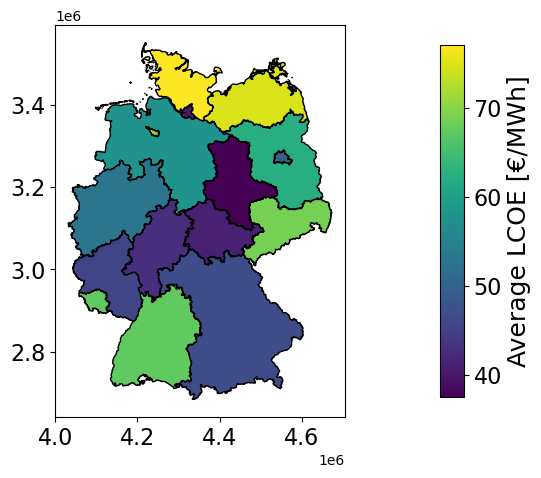

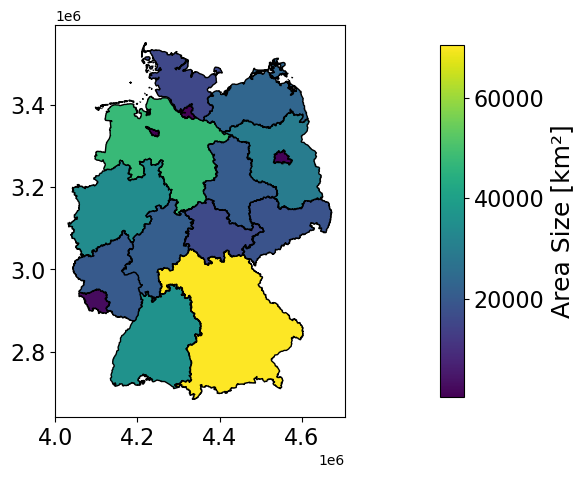

In [55]:
# colored by LCOE

gk.drawGeoms(
    world,
    colorBy="avg_LCOE",
    srs=3035,
    figsize=(6, 4),
    cbar=True,
    cbarTitle="Average LCOE [€/MWh]",
)

# colored by area Size

gk.drawGeoms(
    world,
    colorBy="area_km2",
    srs=3035,
    figsize=(6, 4),
    cbar=True,
    cbarTitle="Area Size [km²]",
)